# Phase 3 — Cleaning, EDA & Feature Engineering

Combines ModCloth + RentTheRunway into one `model_ready` dataset. The reusable
cleaning/parsing logic lives in `src/prepare_data.py` (imported below) so it can
be reused by later phases without duplicating logic; this notebook walks through
*why* each decision was made, with the EDA that motivated it.

**Not done here:** final feature scaling. Scaling is fit inside the Phase 5
train-only pipeline (`sklearn` `Pipeline`/`ColumnTransformer`) so the scaler
never sees test-split statistics — fitting a scaler on the full dataset here
and saving scaled values would leak test-set information into training.

In [1]:
import os
import sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.append(".")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.prepare_data import (
    build_modcloth_frame, build_rtr_frame, build_model_ready,
    MODCLOTH_PATH, RENTTHERUNWAY_PATH, MODCLOTH_DROP_CATEGORIES, SEED,
)

np.random.seed(SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Why the two sources need harmonizing before they can be merged

Phase 2 already found the schemas don't match (different column names, height
as `"5ft 6in"` vs `"5' 8\""`, inches vs bra-band units, etc.). Two more issues
surface once we look at `category` specifically:

In [2]:
modcloth_raw = pd.read_json(MODCLOTH_PATH, lines=True)
rtr_raw = pd.read_json(RENTTHERUNWAY_PATH, lines=True)

print("ModCloth category values (7 total) -- note 'new'/'sale'/'wedding' are")
print("merchandising tags, not garment types:")
print(modcloth_raw["category"].value_counts())
print()
print(f"RentTheRunway has {rtr_raw['category'].nunique()} distinct category values")
print("(much finer-grained than ModCloth's 4 real garment categories) --")
print("e.g.:", list(rtr_raw["category"].value_counts().head(8).index))

ModCloth category values (7 total) -- note 'new'/'sale'/'wedding' are
merchandising tags, not garment types:
category
new          21488
tops         20364
dresses      18650
bottoms      15266
outerwear     4223
sale          2524
wedding        275
Name: count, dtype: int64

RentTheRunway has 68 distinct category values
(much finer-grained than ModCloth's 4 real garment categories) --
e.g.: ['dress', 'gown', 'sheath', 'shift', 'jumpsuit', 'top', 'maxi', 'romper']


**Decisions:**
- Drop ModCloth rows tagged `new`/`sale`/`wedding` (no real garment-category
  signal) -- 24,287 rows, ~29% of ModCloth, ~8.8% of the combined total.
- Map RentTheRunway's 68 fine-grained tags onto the same 4-bucket taxonomy
  ModCloth already uses (`category_broad`), keeping the original as
  `category_detail` for anyone who wants RTR-only granularity.
- Neither dataset has an actual garment-brand field, so `source`
  (modcloth/renttherunway) stands in for "brand" per the data dictionary.

In [3]:
df = build_model_ready()
print(df.shape)
df.head(3)

(251047, 15)


,source,category_detail,category_broad,size_ordered,height_cm,weight_kg,bust_band,bust_cup_ordinal,hip_cm,body_type,fit_feedback,weight_kg_missing,hip_cm_missing,bust_band_missing,bust_cup_ordinal_missing
0,modcloth,dresses,dresses,8,162.56,61.2,34.0,3.0,88.90,not_reported,small,1,0,0,0
1,modcloth,dresses,dresses,8,170.18,61.2,32.0,4.0,99.06,not_reported,fit,1,1,0,0
2,modcloth,dresses,dresses,1,162.56,61.2,32.0,1.0,96.52,not_reported,fit,1,0,0,0


## 2. Missingness is structural, not random

`weight_kg`, `hip_cm` and `body_type` aren't randomly missing -- they're
*entirely absent* from one platform by construction (RentTheRunway never asked
for hips; ModCloth never asked for weight or body type). `waist_cm` was dropped
entirely before this point: once combined, only ~1% of rows have it at all
(ModCloth's own waist field was already 96.5% null on top of RTR having none),
too sparse to impute defensibly.

In [4]:
df.groupby("source")[["weight_kg_missing", "hip_cm_missing"]].mean().round(3)

,weight_kg_missing,hip_cm_missing
source,,
modcloth,1.000,0.32
renttherunway,0.156,1.00


Rather than imputing these with a global median and pretending they're
measured, each gets a `_missing` indicator flag alongside the (source-aware)
median imputation, so models can learn to discount an invented value.
`body_type` similarly gets an explicit `not_reported` category instead of a
guessed body shape -- inventing a protected-attribute-like label would be
risky for the fairness audit in Phase 6.

## 3. Class imbalance in the target

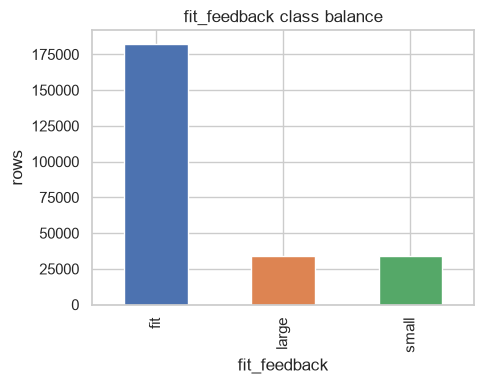

fit_feedback
fit      0.727
large    0.137
small    0.136
Name: proportion, dtype: float64

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
df["fit_feedback"].value_counts().plot.bar(ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("fit_feedback class balance")
ax.set_ylabel("rows")
plt.tight_layout()
plt.show()

df["fit_feedback"].value_counts(normalize=True).round(3)

~73% "fit", ~14% each for "small"/"large" -- confirms the Master Plan's
expectation. This is why F1-macro (not raw accuracy) drives model selection in
Phase 5: a model that always predicts "fit" would score ~73% accuracy while
being useless for the minority classes that actually need a size correction.

## 4. Distributions per fit_feedback class

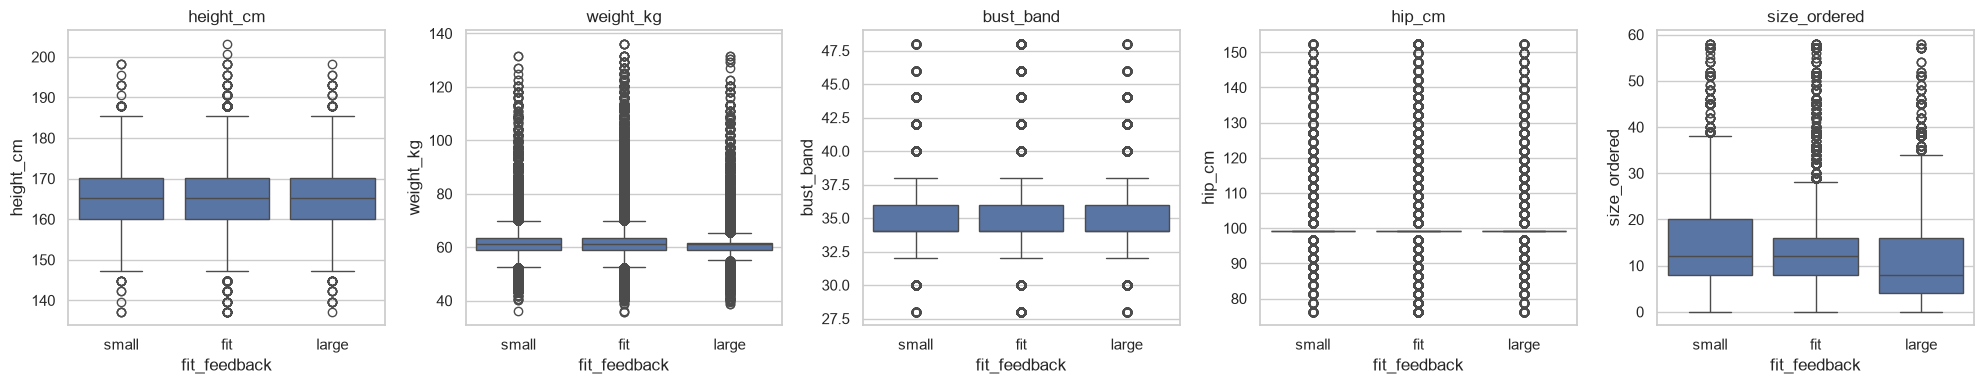

In [6]:
numeric_cols = ["height_cm", "weight_kg", "bust_band", "hip_cm", "size_ordered"]
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4 * len(numeric_cols), 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="fit_feedback", y=col, ax=ax,
                order=["small", "fit", "large"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

`size_ordered` shows the clearest separation (unsurprising -- it's mechanically
tied to fit) while body measurements show much weaker separation on their own,
since fit depends on the *relationship* between measurements and the specific
size ordered, not on measurements in isolation.

## 5. Correlation heatmap (numeric features)

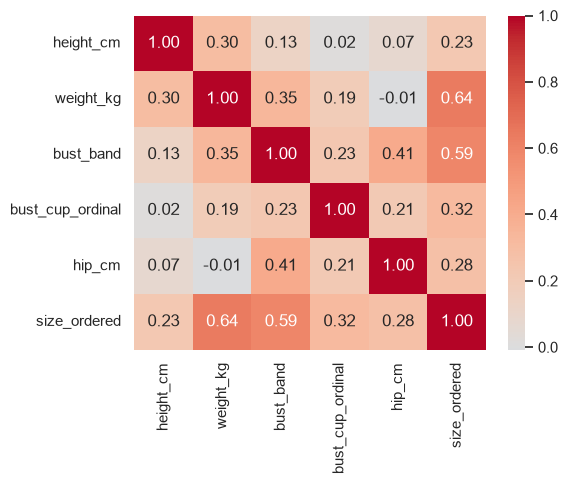

In [7]:
corr_cols = ["height_cm", "weight_kg", "bust_band", "bust_cup_ordinal", "hip_cm", "size_ordered"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.tight_layout()
plt.show()

## 6. Encoding categoricals for modeling

One-hot encode `source`, `category_broad`, `body_type` (nominal, no natural
order). `bust_cup_ordinal` is already numeric (built from the standard bra-cup
progression AA < A < B < ... < K, unifying both datasets' notations via the
documented DD=E, DDD=F, DDDD=G equivalence) so it does not need one-hot
encoding. The target `fit_feedback` is label-encoded preserving order
(small=0, fit=1, large=2) for readability, but is still treated as a nominal
3-class classification target, not ordinal regression, per the Master Plan.

In [8]:
encoded = pd.get_dummies(
    df, columns=["source", "category_broad", "body_type"], drop_first=False
)
fit_order = {"small": 0, "fit": 1, "large": 2}
encoded["fit_feedback_encoded"] = df["fit_feedback"].map(fit_order)
encoded.shape

(251047, 28)

## 7. PCA (2D visualization only -- scaled here for visualization purposes,
   this scaled matrix is not what gets saved to `model_ready.csv`)

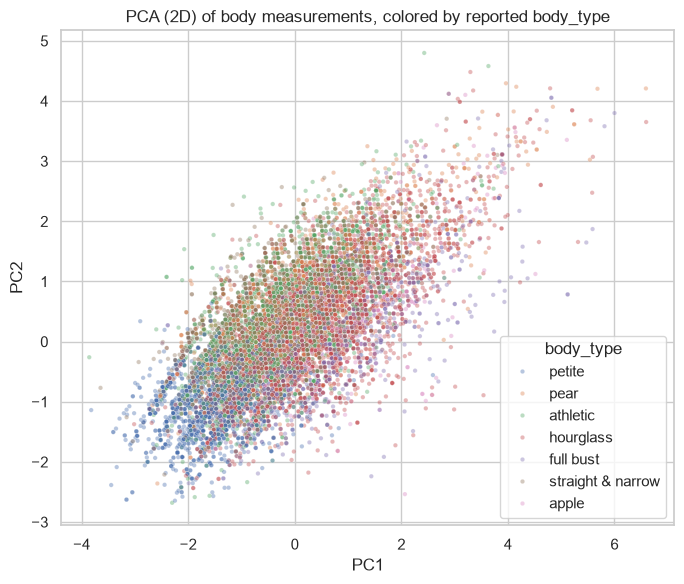

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_features = ["height_cm", "weight_kg", "bust_band", "bust_cup_ordinal", "hip_cm"]
X_scaled = StandardScaler().fit_transform(df[pca_features])
coords = PCA(n_components=2, random_state=SEED).fit_transform(X_scaled)

plot_df = pd.DataFrame(coords, columns=["PC1", "PC2"])
plot_df["body_type"] = df["body_type"].values

labeled = plot_df[plot_df["body_type"] != "not_reported"]
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=labeled.sample(20000, random_state=SEED), x="PC1", y="PC2",
                 hue="body_type", alpha=0.4, s=10, ax=ax)
ax.set_title("PCA (2D) of body measurements, colored by reported body_type")
plt.tight_layout()
plt.show()

Body-type clusters overlap substantially in 2D -- expected, since body shape
categories are defined by proportional relationships between measurements
(e.g. waist-to-hip ratio) rather than absolute size, and PC1/PC2 here are
dominated by overall body size rather than shape. This is a useful negative
result: it suggests raw measurements alone won't trivially separate body
types, reinforcing why the fairness audit (Phase 6) needs per-group metrics
rather than assuming a simple linear boundary.

## 8. Feature selection: tree-based importances (exploratory)

A quick, fixed-seed `RandomForestClassifier` fit on the encoded features to
rank importances. This is exploratory only -- the real model comparison across
LogReg/RF/XGBoost/MLP with a proper train/test split happens in Phase 5.

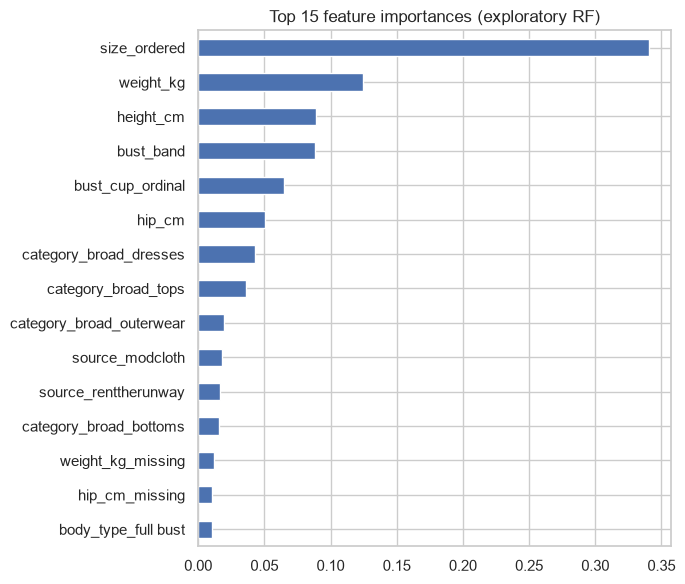

size_ordered                0.340504
weight_kg                   0.124814
height_cm                   0.088820
bust_band                   0.088148
bust_cup_ordinal            0.064487
hip_cm                      0.050641
category_broad_dresses      0.042860
category_broad_tops         0.036426
category_broad_outerwear    0.019831
source_modcloth             0.017654
source_renttherunway        0.016636
category_broad_bottoms      0.015750
weight_kg_missing           0.011881
hip_cm_missing              0.010465
body_type_full bust         0.010194
dtype: float64

In [10]:
from sklearn.ensemble import RandomForestClassifier

feature_cols = [c for c in encoded.columns
                if c not in ["fit_feedback", "fit_feedback_encoded", "category_detail"]]
X = encoded[feature_cols]
y = encoded["fit_feedback_encoded"]

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 6))
importances.head(15).plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_title("Top 15 feature importances (exploratory RF)")
plt.tight_layout()
plt.show()

importances.head(15)

`size_ordered` dominates, as expected (it's mechanically the closest signal to
fit outcome), followed by the body-measurement fields. The `_missing`
indicator flags and one-hot category/source columns rank low individually but
are kept -- Phase 5 will use the same encoded feature set across all four
models for a fair comparison.

## 9. Save model_ready dataset

`data/processed/model_ready.csv` is saved by `src/prepare_data.py` directly
(run via `python src/prepare_data.py`) in its **unscaled, imputed, encoded-
ready-but-not-yet-one-hot-encoded** form -- Phase 5 applies one-hot encoding
and scaling inside a train-only-fit pipeline to avoid any leakage.

In [11]:
import subprocess
result = subprocess.run(
    [sys.executable, "src/prepare_data.py"],
    capture_output=True, text=True,
)
print(result.stdout)
print(result.stderr)

Saved 251,047 rows x 15 cols to data/processed/model_ready.csv

dtypes:
 source                          str
category_detail                 str
category_broad                  str
size_ordered                  int64
height_cm                   float64
weight_kg                   float64
bust_band                   float64
bust_cup_ordinal            float64
hip_cm                      float64
body_type                    object
fit_feedback                    str
weight_kg_missing             int64
hip_cm_missing                int64
bust_band_missing             int64
bust_cup_ordinal_missing      int64
dtype: object

fit_feedback distribution:
 fit_feedback
fit      0.727
large    0.137
small    0.136
Name: proportion, dtype: float64

source distribution:
 source
renttherunway    192544
modcloth          58503
Name: count, dtype: int64

remaining nulls:
 Series([], dtype: int64)


